Analysis Started...
Total Sales: $1,565,804.32
Total Profit: $175,262.11
Saved: 1_sales_by_subcategory.png
Saved: 2_monthly_sales_trend.png
Saved: 3_regional_sales_pie.png
Saved: 4_payment_profit.png


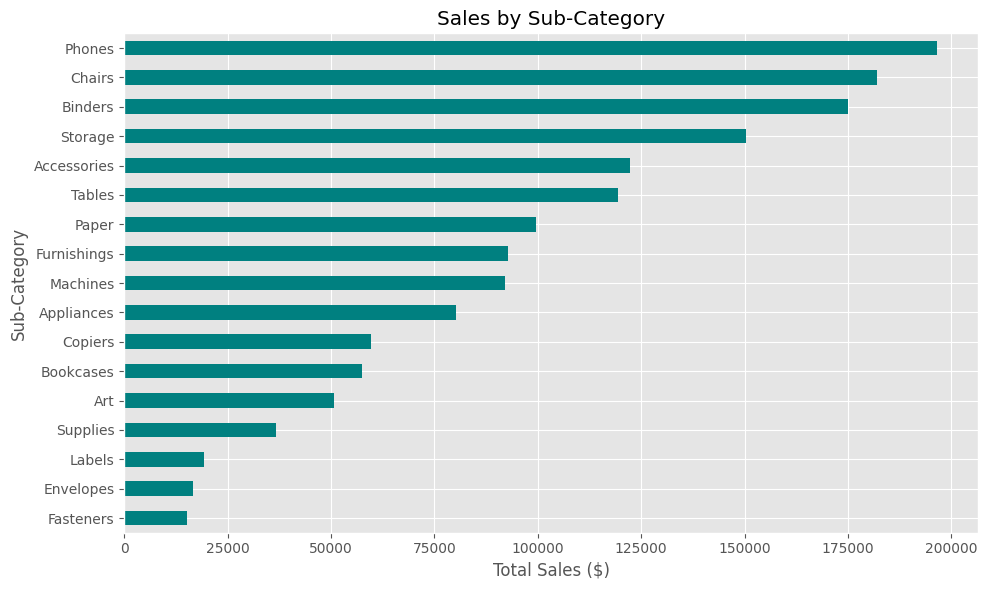

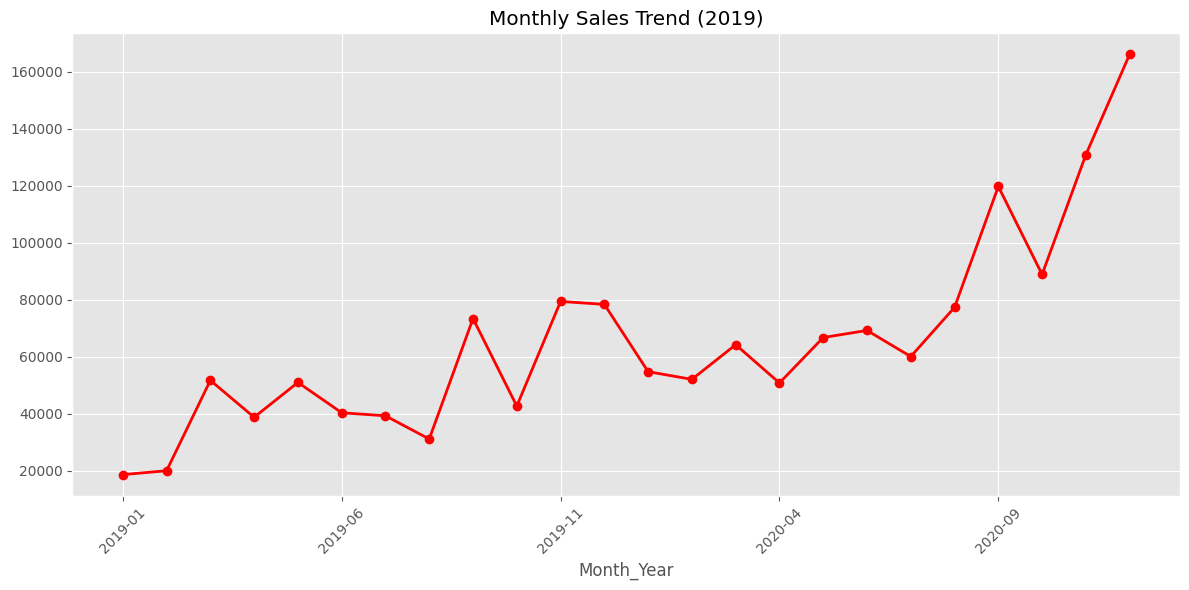

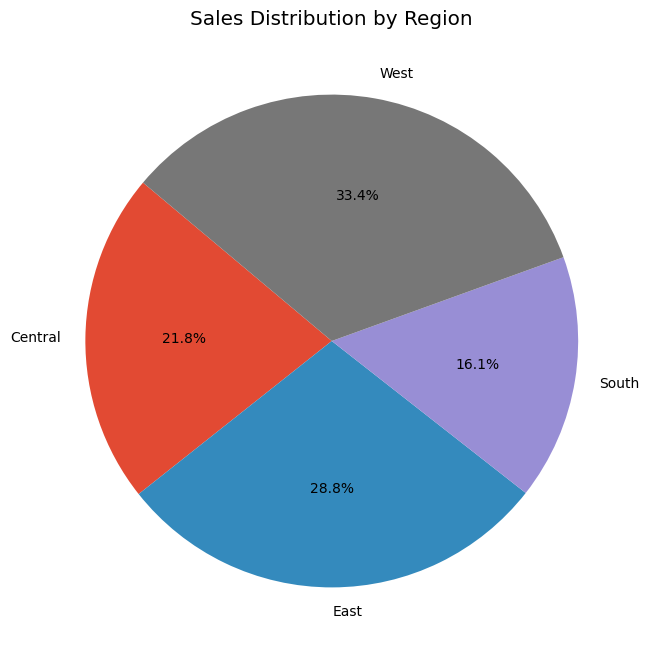

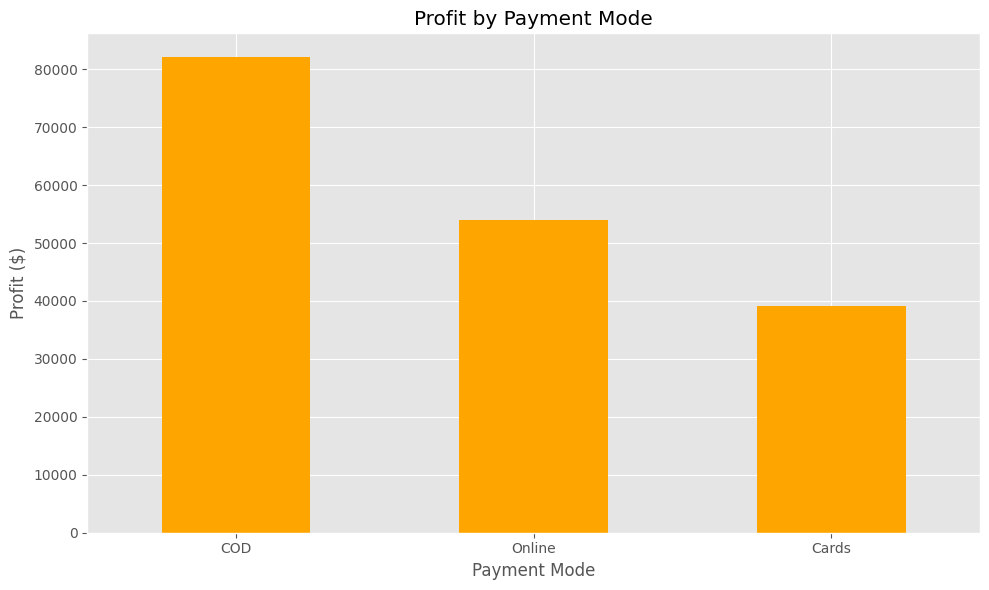


✅ Saari images aapke folder mein save ho gayi hain!
✅ Dashboard saved as: Sales_Dashboard_Subplot.png


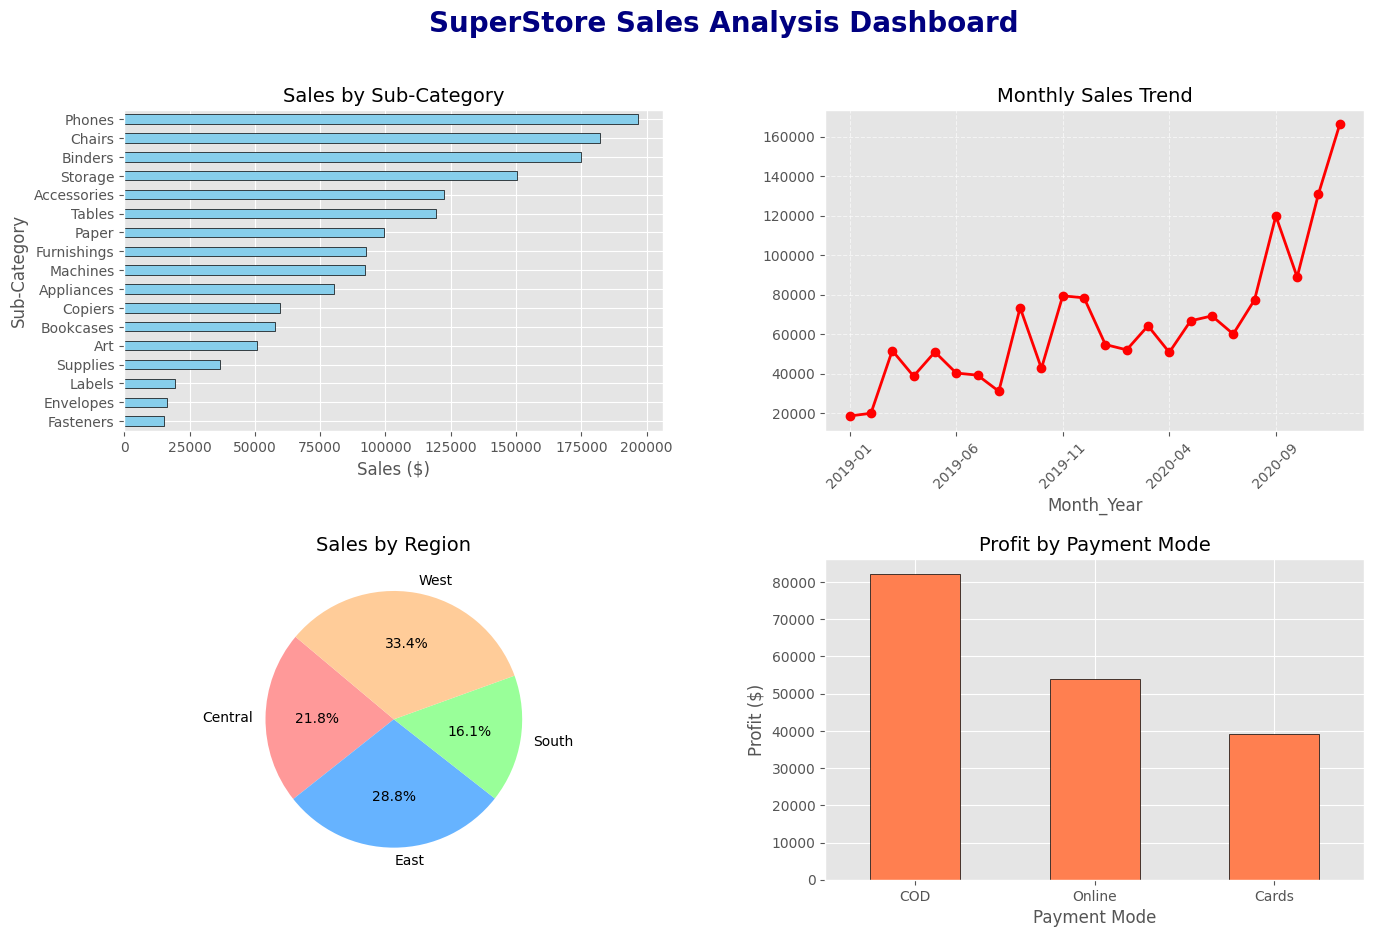

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Load karein

df = pd.read_csv('SuperStore_Sales_Dataset (1).csv')

# 2. Data Cleaning & Formatting
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Month_Year'] = df['Order Date'].dt.to_period('M').astype(str)

# --- Calculations (Power BI style) ---
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print(f"Analysis Started...")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")

# 3. Visualizations aur Saving Figures
plt.style.use('ggplot') # Sundar look ke liye

# --- FIGURE 1: Sales by Sub-Category ---
plt.figure(figsize=(10, 6))
df.groupby('Sub-Category')['Sales'].sum().sort_values().plot(kind='barh', color='teal')
plt.title('Sales by Sub-Category')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('1_sales_by_subcategory.png') 
print("Saved: 1_sales_by_subcategory.png")

# --- FIGURE 2: Monthly Sales Trend ---
plt.figure(figsize=(12, 6))
df.groupby('Month_Year')['Sales'].sum().plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('Monthly Sales Trend (2019)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('2_monthly_sales_trend.png') 
print("Saved: 2_monthly_sales_trend.png")

# --- FIGURE 3: Sales by Region (Pie Chart) ---
plt.figure(figsize=(8, 8))
df.groupby('Region')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Sales Distribution by Region')
plt.ylabel('') 
plt.savefig('3_regional_sales_pie.png') 
print("Saved: 3_regional_sales_pie.png")

# --- FIGURE 4: Profit by Payment Mode ---
plt.figure(figsize=(10, 6))
df.groupby('Payment Mode')['Profit'].sum().sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Profit by Payment Mode')
plt.ylabel('Profit ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('4_payment_profit.png') 
print("Saved: 4_payment_profit.png")

plt.show()




# 2. Data Cleaning
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Month_Year'] = df['Order Date'].dt.to_period('M').astype(str)

# 3. Create Dashboard Figure (Subplots)
# figsize(16, 10) matlab width 16 aur height 10 inch
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3) # Graphs ke beech gap ke liye
plt.suptitle('SuperStore Sales Analysis Dashboard', fontsize=20, fontweight='bold', color='navy')

# --- Subplot 1: Sales by Sub-Category (Top Left) ---
sub_cat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values()
sub_cat_sales.plot(kind='barh', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Sales by Sub-Category', fontsize=14)
axes[0, 0].set_xlabel('Sales ($)')

# --- Subplot 2: Monthly Sales Trend (Top Right) ---
monthly_trend = df.groupby('Month_Year')['Sales'].sum()
monthly_trend.plot(kind='line', ax=axes[0, 1], marker='o', color='red', linewidth=2)
axes[0, 1].set_title('Monthly Sales Trend', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# --- Subplot 3: Regional Sales Distribution (Bottom Left) ---
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='pie', ax=axes[1, 0], autopct='%1.1f%%', startangle=140, 
                  colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[1, 0].set_title('Sales by Region', fontsize=14)
axes[1, 0].set_ylabel('') # Y-label hatane ke liye

# --- Subplot 4: Profit by Payment Mode (Bottom Right) ---
payment_profit = df.groupby('Payment Mode')['Profit'].sum().sort_values(ascending=False)
payment_profit.plot(kind='bar', ax=axes[1, 1], color='coral', edgecolor='black')
axes[1, 1].set_title('Profit by Payment Mode', fontsize=14)
axes[1, 1].set_ylabel('Profit ($)')
axes[1, 1].tick_params(axis='x', rotation=0)

# 4. Save the entire Dashboard as one image
plt.savefig('Sales_Dashboard_Subplot.png', dpi=300, bbox_inches='tight')
print("✅ Dashboard saved as: Sales_Dashboard_Subplot.png")

# 5. Show the plot
plt.show()